# RAG & Agent Evaluation — LangGraph + Real OpenAI Calls

This is the live-LLM counterpart to `rag_agent_eval_langgraph.ipynb`. Same eval concepts, same graph shapes, but the mock judge/planner functions are replaced with **real `ChatOpenAI` calls**:

1. Part 1 — RAG retrieval metrics (Precision@K, Recall@K, MRR, nDCG) — unchanged, these are deterministic math, no LLM needed.
2. Part 2 — RAG eval pipeline as a LangGraph graph, using a real OpenAI model as the **LLM-as-judge** for context relevance + faithfulness, and a real OpenAI call to generate the answer.
3. Part 3 — Agent eval pipeline as a LangGraph graph, using a real OpenAI **tool-calling agent** (the model itself decides which tool to call and when to stop) plus a separate eval harness that scores the resulting trace against a gold trajectory.

**Requirements:** `OPENAI_API_KEY` set in your environment or in a `.env` file at the project root.

## Setup

In [ ]:
# pip install langgraph langchain-core langchain-openai python-dotenv

In [1]:
import json
import math
import os
from typing import Dict, List, Optional, TypedDict

from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from pydantic import BaseModel, Field

load_dotenv()  # picks up OPENAI_API_KEY from a .env file at the project root

assert os.environ.get("OPENAI_API_KEY"), (
    "Set OPENAI_API_KEY (in your shell env or in a .env file) before running this notebook."
)

MODEL_NAME = "gpt-4o-mini"

# temperature=0 everywhere: eval judges and planners should be as deterministic as possible
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

print(f"OpenAI client ready — model={MODEL_NAME}")

OpenAI client ready — model=gpt-4o-mini


---
# Part 1 — Retrieval Metrics

**Interview questions covered:**
- *How would you evaluate retrieval quality?*
- *What do Precision@K and Recall@K tell you?*
- *When would you use MRR or nDCG?*

These are pure ranking math — no LLM call belongs here. Kept identical to the mock notebook so retrieval quality stays isolated from generation quality.

In [2]:
def precision_at_k(retrieved: List[str], relevant: List[str], k: int) -> float:
    """Of the K chunks retrieved, how many are actually relevant?"""
    top_k = retrieved[:k]
    hits = [doc for doc in top_k if doc in relevant]
    return len(hits) / k if k > 0 else 0.0


def recall_at_k(retrieved: List[str], relevant: List[str], k: int) -> float:
    """Of all relevant chunks that exist, how many did we find in top K?"""
    top_k = retrieved[:k]
    hits = [doc for doc in top_k if doc in relevant]
    return len(hits) / len(relevant) if relevant else 0.0


def mrr(retrieved: List[str], relevant: List[str]) -> float:
    """Mean Reciprocal Rank: 1/rank of the FIRST relevant hit.
    Use when there's typically one correct/best chunk and you care how early it appears."""
    for rank, doc in enumerate(retrieved, start=1):
        if doc in relevant:
            return 1.0 / rank
    return 0.0


def dcg_at_k(retrieved: List[str], grades: Dict[str, int], k: int) -> float:
    score = 0.0
    for i, doc in enumerate(retrieved[:k]):
        rel = grades.get(doc, 0)
        score += rel / math.log2(i + 2)  # rank 1 -> log2(2)=1, avoids log2(1)=0 division
    return score


def ndcg_at_k(retrieved: List[str], grades: Dict[str, int], k: int) -> float:
    """Normalized DCG: use when relevance is GRADED (not binary) and multiple
    relevant chunks can coexist. Rewards relevant results appearing higher."""
    dcg = dcg_at_k(retrieved, grades, k)
    ideal_order = sorted(grades.values(), reverse=True)[:k]
    idcg = sum(rel / math.log2(i + 2) for i, rel in enumerate(ideal_order))
    return dcg / idcg if idcg > 0 else 0.0


print("Metric functions defined")

Metric functions defined


In [3]:
query = "What is the time complexity of BST delete?"

retrieved_ids = ["chunk_3", "chunk_1", "chunk_7", "chunk_2", "chunk_9"]
relevant_ids = ["chunk_1", "chunk_2", "chunk_5"]  # chunk_5 exists but wasn't retrieved -> hurts recall
relevance_grades = {
    "chunk_1": 3, "chunk_2": 2, "chunk_3": 0,
    "chunk_5": 3, "chunk_7": 1, "chunk_9": 0,
}

k = 5
print(f"Precision@{k}: {precision_at_k(retrieved_ids, relevant_ids, k):.2f}")
print(f"Recall@{k}:    {recall_at_k(retrieved_ids, relevant_ids, k):.2f}")
print(f"MRR:           {mrr(retrieved_ids, relevant_ids):.2f}")
print(f"nDCG@{k}:       {ndcg_at_k(retrieved_ids, relevance_grades, k):.2f}")

Precision@5: 0.40
Recall@5:    0.67
MRR:           0.50
nDCG@5:       0.51


---
# Part 2 — RAG Eval Pipeline as a LangGraph Graph (real OpenAI calls)

**Interview questions covered:**
- *How would you measure context relevance?*
- *How would you know the answer is grounded in the retrieved context?*

Same graph shape as the mock notebook — `retrieve -> judge_context_relevance -> generate -> check_faithfulness` — but every judge and the generator are now real `ChatOpenAI` calls. Structured output (`with_structured_output`) is used so the judge returns a typed verdict instead of free text you'd have to parse.

In [4]:
class RAGEvalState(TypedDict):
    query: str
    retrieved_chunks: List[Dict]
    relevance_judgments: Dict[str, str]      # chunk_id -> "relevant" / "irrelevant"
    answer: str
    claims: List[str]
    faithfulness_scores: Dict[str, bool]     # claim -> is it supported by context?
    context_relevance_score: float
    faithfulness_score: float

In [5]:
# ---- Real LLM-as-judge, via structured output ----

class RelevanceVerdict(BaseModel):
    verdict: str = Field(description='Either "relevant" or "irrelevant"')


class FaithfulnessVerdict(BaseModel):
    supported: bool = Field(description="True if the claim is entailed by the provided context")


class ExtractedClaims(BaseModel):
    claims: List[str] = Field(description="Atomic factual claims made in the answer, one per list item")


relevance_judge = llm.with_structured_output(RelevanceVerdict)
faithfulness_judge = llm.with_structured_output(FaithfulnessVerdict)
claim_extractor = llm.with_structured_output(ExtractedClaims)


def llm_judge_relevance(query: str, chunk_text: str) -> str:
    result = relevance_judge.invoke([
        SystemMessage("You judge whether a retrieved passage is relevant to a query. "
                       'Answer with exactly "relevant" or "irrelevant".'),
        HumanMessage(f"Query: {query}\n\nPassage: {chunk_text}"),
    ])
    return result.verdict.strip().lower()


def llm_generate_answer(query: str, chunks: List[Dict]) -> str:
    context = "\n".join(f"- {c['text']}" for c in chunks)
    result = llm.invoke([
        SystemMessage("Answer the question using ONLY the provided context. Be concise (1-2 sentences). "
                       "If the context is insufficient, say so."),
        HumanMessage(f"Context:\n{context}\n\nQuestion: {query}"),
    ])
    return result.content


def llm_extract_claims(answer: str) -> List[str]:
    result = claim_extractor.invoke([
        SystemMessage("Split the answer into a list of atomic, independently-checkable factual claims."),
        HumanMessage(answer),
    ])
    return result.claims


def llm_check_claim_supported(claim: str, chunks: List[Dict]) -> bool:
    context = "\n".join(f"- {c['text']}" for c in chunks)
    result = faithfulness_judge.invoke([
        SystemMessage("You check whether a claim is fully supported (entailed) by the given context. "
                       "Do not use outside knowledge."),
        HumanMessage(f"Context:\n{context}\n\nClaim: {claim}"),
    ])
    return result.supported


print("Real LLM judges defined")

Real LLM judges defined


In [6]:
def retrieve_node(state: RAGEvalState) -> RAGEvalState:
    # In a real pipeline this is a vector search call. Fixture data here for a
    # reproducible demo -- notice c3 is deliberately off-topic.
    state["retrieved_chunks"] = [
        {"id": "c1", "text": "BST delete runs in O(h) time where h is tree height."},
        {"id": "c2", "text": "The successor node is the leftmost node of the right subtree."},
        {"id": "c3", "text": "Unrelated: Python lists are dynamic arrays."},
    ]
    return state


def judge_context_relevance_node(state: RAGEvalState) -> RAGEvalState:
    judgments = {
        c["id"]: llm_judge_relevance(state["query"], c["text"])
        for c in state["retrieved_chunks"]
    }
    state["relevance_judgments"] = judgments
    relevant_count = sum(1 for v in judgments.values() if v == "relevant")
    state["context_relevance_score"] = relevant_count / len(judgments)
    return state


def generate_node(state: RAGEvalState) -> RAGEvalState:
    # Only feed relevant chunks into generation -- filter before you generate,
    # don't just filter the eval after the fact.
    relevant_chunks = [
        c for c in state["retrieved_chunks"]
        if state["relevance_judgments"][c["id"]] == "relevant"
    ]
    state["answer"] = llm_generate_answer(state["query"], relevant_chunks)
    return state


def check_faithfulness_node(state: RAGEvalState) -> RAGEvalState:
    claims = llm_extract_claims(state["answer"])
    state["claims"] = claims
    scores = {c: llm_check_claim_supported(c, state["retrieved_chunks"]) for c in claims}
    state["faithfulness_scores"] = scores
    supported = sum(1 for v in scores.values() if v)
    state["faithfulness_score"] = supported / len(scores) if scores else 0.0
    return state


print("Nodes defined")

Nodes defined


In [7]:
builder = StateGraph(RAGEvalState)
builder.add_node("retrieve", retrieve_node)
builder.add_node("judge_context_relevance", judge_context_relevance_node)
builder.add_node("generate", generate_node)
builder.add_node("check_faithfulness", check_faithfulness_node)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "judge_context_relevance")
builder.add_edge("judge_context_relevance", "generate")
builder.add_edge("generate", "check_faithfulness")
builder.add_edge("check_faithfulness", END)

rag_eval_graph = builder.compile()
print("Graph compiled: retrieve -> judge_context_relevance -> generate -> check_faithfulness -> END")

Graph compiled: retrieve -> judge_context_relevance -> generate -> check_faithfulness -> END


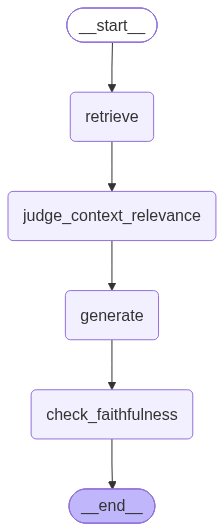

In [8]:
rag_eval_graph

In [9]:
result = rag_eval_graph.invoke({"query": "What is the time complexity of BST delete?"})

print("Context relevance judgments:", result["relevance_judgments"])
print(f"Context relevance score:      {result['context_relevance_score']:.2f}")
print()
print("Answer:", result["answer"])
print("Claims:", result["claims"])
print("Faithfulness scores:", result["faithfulness_scores"])
print(f"Faithfulness score:           {result['faithfulness_score']:.2f}")

Context relevance judgments: {'c1': 'relevant', 'c2': 'irrelevant', 'c3': 'irrelevant'}
Context relevance score:      0.33

Answer: The time complexity of BST delete is O(h), where h is the height of the tree.
Claims: ['The time complexity of deleting a node from a Binary Search Tree (BST) is O(h).', 'h represents the height of the Binary Search Tree.']
Faithfulness scores: {'The time complexity of deleting a node from a Binary Search Tree (BST) is O(h).': True, 'h represents the height of the Binary Search Tree.': True}
Faithfulness score:           1.00


**Reading the output:** unlike the mock notebook, the exact judgments and claim wording here can vary slightly run-to-run because a real model is making the call (this is itself an interview point — LLM-as-judge is noisier than a deterministic mock, which is why production evals typically run each judge multiple times / use `temperature=0` / track judge-agreement as its own metric).

---
# Part 3 — Agent Eval Pipeline as a LangGraph Graph (real OpenAI tool-calling agent)

**Interview questions covered:**
- *How would you evaluate whether the agent selected the right tool?*
- *How would you measure task completion?*
- *What happens when the agent takes the wrong action?*
- *How would you evaluate multi-step tasks?*
- *How would you detect unnecessary tool calls?*

This time the planner is a real `ChatOpenAI` model with tools bound via `bind_tools` — the model itself decides which tool to call, with what arguments, and when it's done. The graph loops `agent -> tools -> agent -> ...` until the model responds without requesting a tool call, then hands the resulting trace to a separate `evaluate` node that scores it against a gold trajectory (mirrors real practice: the agent never grades itself).

In [10]:
# ---- Real tools the agent can call ----

@tool
def search_docs(topic: str) -> str:
    """Search internal docs for information about a topic."""
    return f"docs about {topic}: BST delete runs in O(h) time where h is tree height."


@tool
def calculator(expr: str) -> str:
    """Evaluate a simple arithmetic expression, e.g. '2**10'."""
    allowed = set("0123456789+-*/(). ")
    if not set(expr) <= allowed:
        return "error: expression contains disallowed characters"
    return str(eval(expr, {"__builtins__": {}}, {}))


@tool
def send_email(to: str, body: str) -> str:
    """Send an email to a recipient."""
    return f"email sent to {to}"


TOOLS = [search_docs, calculator, send_email]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}
agent_llm = llm.bind_tools(TOOLS)

print("Tools registered:", list(TOOLS_BY_NAME.keys()))

Tools registered: ['search_docs', 'calculator', 'send_email']


In [11]:
class AgentEvalState(TypedDict):
    query: str
    gold_tool_sequence: List[str]     # ground truth trajectory, defined by the eval harness
    messages: List                    # the real conversation, incl. tool calls/results
    trace: List[Dict]                 # [{"tool", "args", "result", "used"}]
    final_answer: Optional[str]
    task_success: Optional[bool]
    tool_selection_correct: List[bool]
    unnecessary_calls: List[str]

In [12]:
MAX_STEPS = 6  # safety cap so a misbehaving agent can't loop forever


def agent_node(state: AgentEvalState) -> AgentEvalState:
    if not state["messages"]:
        state["messages"] = [
            SystemMessage("You are a helpful assistant. Use tools when needed to answer the "
                          "user's request, then give a final natural-language answer. Do not "
                          "call the same tool with the same arguments twice."),
            HumanMessage(state["query"]),
        ]

    response: AIMessage = agent_llm.invoke(state["messages"])
    state["messages"] = state["messages"] + [response]

    if not response.tool_calls:
        state["final_answer"] = response.content

    return state


def tools_node(state: AgentEvalState) -> AgentEvalState:
    last_message: AIMessage = state["messages"][-1]
    tool_messages = []

    for call in last_message.tool_calls:
        tool_name, args = call["name"], call["args"]

        # A call is "unnecessary" if the exact same (tool, args) already ran --
        # the result would be identical, so it added no new information.
        is_duplicate = any(t["tool"] == tool_name and t["args"] == args for t in state["trace"])

        result = TOOLS_BY_NAME[tool_name].invoke(args)
        state["trace"].append({
            "tool": tool_name, "args": args, "result": result, "used": not is_duplicate,
        })
        tool_messages.append(ToolMessage(content=str(result), tool_call_id=call["id"]))

    state["messages"] = state["messages"] + tool_messages
    return state


def should_continue(state: AgentEvalState) -> str:
    if state.get("final_answer") is not None:
        return "evaluate"
    if len(state["trace"]) >= MAX_STEPS:
        state["final_answer"] = "Task stopped: exceeded max tool-call budget."
        return "evaluate"
    return "tools"


def evaluate_node(state: AgentEvalState) -> AgentEvalState:
    actual_tools = [t["tool"] for t in state["trace"]]
    gold_tools = state["gold_tool_sequence"]

    # Step-wise trajectory match against the gold sequence -- this is how you
    # evaluate MULTI-STEP tasks: score each step, not just the final answer.
    correctness = [
        (actual_tools[i] if i < len(actual_tools) else None) == gold_tools[i]
        for i in range(len(gold_tools))
    ]
    state["tool_selection_correct"] = correctness

    # Flags raised during the trace itself -- redundant calls with no new info.
    state["unnecessary_calls"] = [t["tool"] for t in state["trace"] if not t["used"]]

    # Task completion = reached a final answer AND every gold step was matched.
    state["task_success"] = (
        state["final_answer"] is not None and sum(correctness) == len(gold_tools)
    )
    return state


print("Nodes defined (agent_node calls the real OpenAI model)")

Nodes defined (agent_node calls the real OpenAI model)


In [13]:
builder = StateGraph(AgentEvalState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tools_node)
builder.add_node("evaluate", evaluate_node)

builder.set_entry_point("agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", "evaluate": "evaluate"})
builder.add_edge("tools", "agent")
builder.add_edge("evaluate", END)

agent_eval_graph = builder.compile()
print("Graph compiled: agent <-> tools (loops), agent -> evaluate -> END")

Graph compiled: agent <-> tools (loops), agent -> evaluate -> END


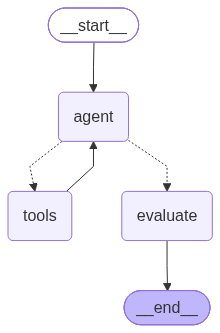

In [15]:
agent_eval_graph

In [14]:
initial_state: AgentEvalState = {
    "query": "Look up BST delete complexity and compute 2^10",
    "gold_tool_sequence": ["search_docs", "calculator"],   # the IDEAL 2-step trajectory
    "messages": [],
    "trace": [],
    "final_answer": None,
    "task_success": None,
    "tool_selection_correct": [],
    "unnecessary_calls": [],
}

result = agent_eval_graph.invoke(initial_state)

print("=== Trace ===")
for i, step in enumerate(result["trace"]):
    print(f"  Step {i}: {step['tool']}({step['args']}) -> {step['result']!r}  | used={step['used']}")

print()
print("=== Eval ===")
print("Tool selection correctness vs gold:", result["tool_selection_correct"])
print("Unnecessary calls detected:        ", result["unnecessary_calls"])
print("Task success:                      ", result["task_success"])
print("Final answer:                      ", result["final_answer"])

=== Trace ===
  Step 0: search_docs({'topic': 'BST delete complexity'}) -> 'docs about BST delete complexity: BST delete runs in O(h) time where h is tree height.'  | used=True
  Step 1: calculator({'expr': '2**10'}) -> '1024'  | used=True

=== Eval ===
Tool selection correctness vs gold: [True, True]
Unnecessary calls detected:         []
Task success:                       True
Final answer:                       The complexity of deleting a node from a Binary Search Tree (BST) is \( O(h) \), where \( h \) is the height of the tree. 

Additionally, \( 2^{10} \) equals 1024.


**Reading the output:** unlike the mock notebook (which hard-coded a redundant call to *force* the demo), a real, reasonably capable model will usually pick the correct minimal trajectory (`search_docs` then `calculator`) and avoid duplicate calls on its own. That itself is a finding worth stating in an interview: mocked agent demos need synthetic failures injected, but a real deployed agent needs a harness like this `evaluate` node running continuously in production to catch the cases where the model *doesn't* behave well — e.g. try changing the query to something ambiguous, or add a fourth tool the model might reach for unnecessarily, and re-run this cell to see the eval flag it.

---
## Summary — mapping back to the interview answers

| Question | Where in this notebook |
|---|---|
| How would you evaluate retrieval quality? | Part 1 — full metric suite run against a labeled query |
| Precision@K / Recall@K | Part 1 — `precision_at_k`, `recall_at_k` |
| When MRR vs nDCG? | Part 1 — `mrr` (single best answer) vs `ndcg_at_k` (graded, multiple relevant) |
| Context relevance | Part 2 — `judge_context_relevance_node`, real `ChatOpenAI` judge, scored *before* generation |
| Groundedness / faithfulness | Part 2 — `check_faithfulness_node`, real `ChatOpenAI` claim-by-claim check *after* generation |
| Right tool selected? | Part 3 — `tool_selection_correct`, step-wise match vs gold trajectory, produced by a real tool-calling agent |
| Task completion | Part 3 — `task_success`, requires final answer AND full trajectory match |
| Wrong action taken | Part 3 — the `evaluate` node catches it post-hoc; a production system would also guard pre-call (e.g. dedupe check before invoking) |
| Multi-step evaluation | Part 3 — step-wise trajectory scoring over a real `agent <-> tools` loop, not just final-answer scoring |
| Unnecessary tool calls | Part 3 — `unnecessary_calls`, duplicate `(tool, args)` detection against the live trace |